In [ ]:
# Data Preprocessing
# IMport Libraries

# daAta manipulation
import pandas as pd
import numpy as np

# visual and graphs
import matplotlib.pyplot as plt

# ml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# display settings
# pd.set_option("display.max_columns", None)

In [21]:
# Load the Dataset
df = pd.read_csv("../data/customer_churn.csv")

# Display first few rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [22]:
# basic overview
print("dataset-shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

dataset-shape: (64374, 12)

Columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Data Types:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object


In [23]:
# checking missing values
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Total Missing Values: 0


In [24]:
# checking duplicates
duplicates = df.duplicated().sum()
print("duplicate rows:", duplicates)

duplicate rows: 0


# to remove customer-if column as it does not help predict customer churn, and may introduce noise.

In [25]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [26]:
df = df.drop(columns=["CustomerID"])

print(df.head())

   Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0   22  Female      25               14              4             27   
1   41  Female      28               28              7             13   
2   47    Male      27               10              2             29   
3   35    Male       9               12              5             17   
4   53  Female      58               24              9              2   

  Subscription Type Contract Length  Total Spend  Last Interaction  Churn  
0             Basic         Monthly          598                 9      1  
1          Standard         Monthly          584                20      0  
2           Premium          Annual          757                21      0  
3           Premium       Quarterly          232                18      0  
4          Standard          Annual          533                18      0  


In [27]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [29]:
df["Churn"].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [30]:
# check Target variable = 'Churn'
print("Target Distribution:")
print(df["Churn"].value_counts())

print("\nPercentage Distribution:")
print(df["Churn"].value_counts(normalize=True) * 100) # normalise true returns proportions bw 0 and 1
# 0 -> customer stayed
# 1-> customer churned

Target Distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64

Percentage Distribution:
Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


In [32]:
df.shape

(64374, 11)

In [31]:
# separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (64374, 10)
Target Shape: (64374,)


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                64374 non-null  int64 
 1   Gender             64374 non-null  object
 2   Tenure             64374 non-null  int64 
 3   Usage Frequency    64374 non-null  int64 
 4   Support Calls      64374 non-null  int64 
 5   Payment Delay      64374 non-null  int64 
 6   Subscription Type  64374 non-null  object
 7   Contract Length    64374 non-null  object
 8   Total Spend        64374 non-null  int64 
 9   Last Interaction   64374 non-null  int64 
 10  Churn              64374 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 5.4+ MB


In [34]:
# numerical or categorical data?
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Gender', 'Subscription Type', 'Contract Length']

Numerical Features:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']


In [ ]:
# pipeline
preprocessor = ColumnTransformer(
    transformers=[(
        "cat",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_features),
        ("num",
         "passthrough",
         numerical_features)]
)

In [38]:
# splitting of thd data
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("training Shape:", X_train.shape)
print("testing Shape :", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True)*100)

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True)*100)

training Shape: (51499, 10)
testing Shape : (12875, 10)

Training Target Distribution:
Churn
0    52.63209
1    47.36791
Name: proportion, dtype: float64

Testing Target Distribution:
Churn
0    52.629126
1    47.370874
Name: proportion, dtype: float64


In [39]:
#------------------
#Phase 2
# EDA
#----------------------
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "DejaVu Sans"
})
# good ^^


In [42]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

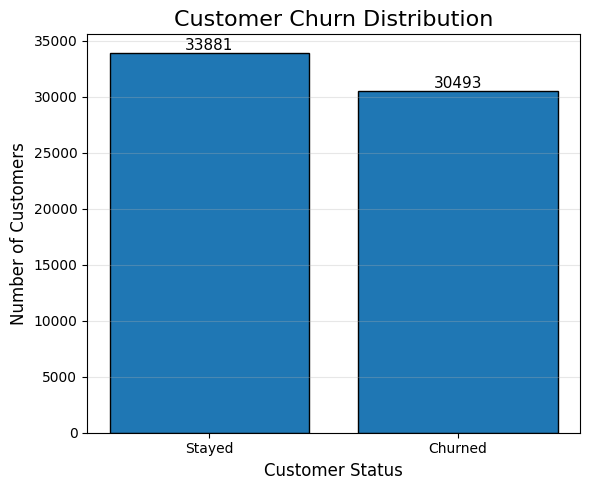

In [43]:
# churn distribution
churn_counts = df["Churn"].value_counts().sort_index()

plt.figure(figsize=(6,5))
bars = plt.bar(
    ["Stayed", "Churned"],
    churn_counts.values,
    edgecolor="black"
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

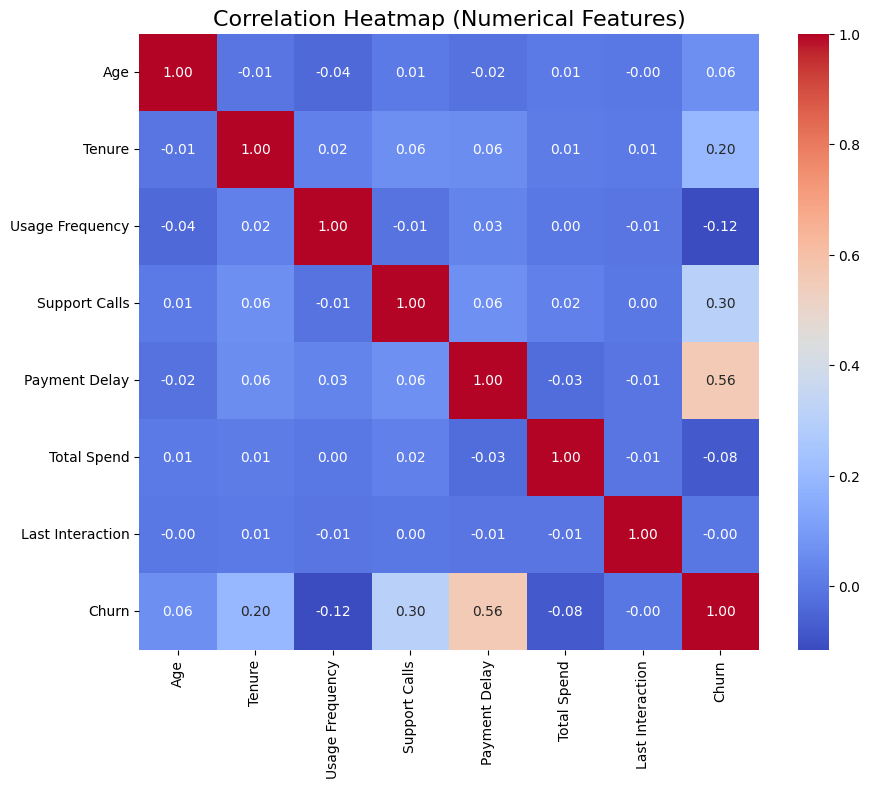

In [45]:
# correlation heatmap
# only numeric, obvious
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

import seaborn as sns

plt.figure(figsize=(10, 8))

# annot=True works here flawlessly
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

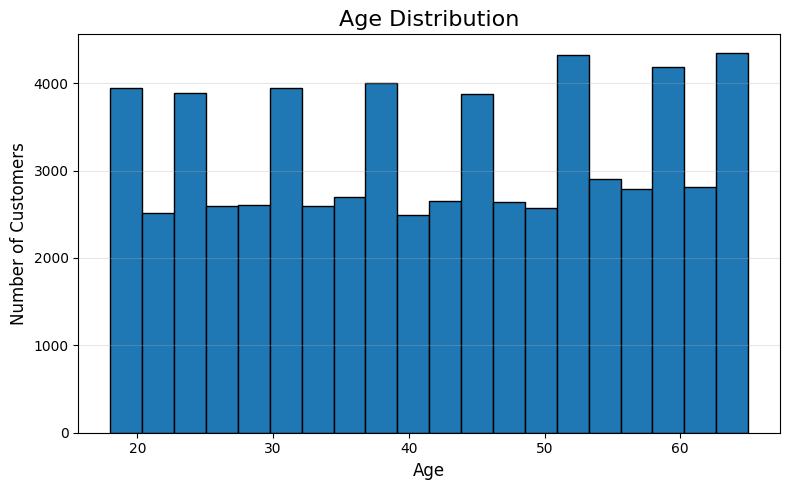

In [ ]:
#age distribution, 
# histogram for contunuous numerical variable=> age
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

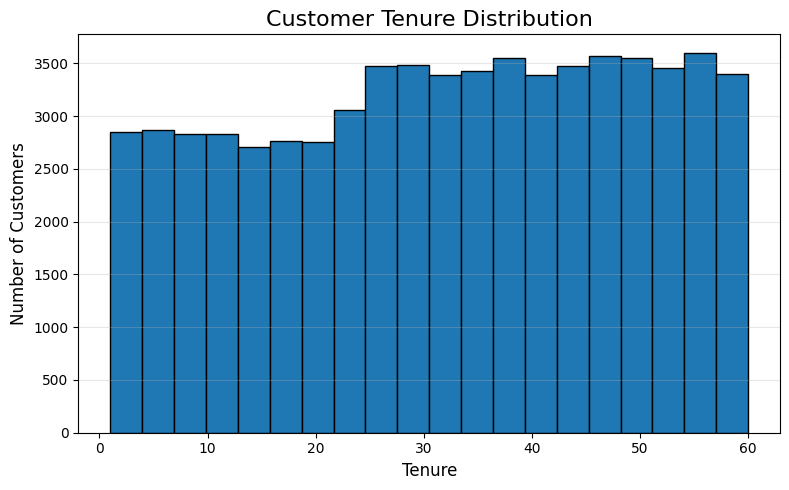

In [47]:
# Tenure distribution
#Shows how long custo stay.
#customers with  short tenure have higher churn.

plt.figure(figsize=(8,5))

plt.hist(df["Tenure"], bins=20, edgecolor="black")

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

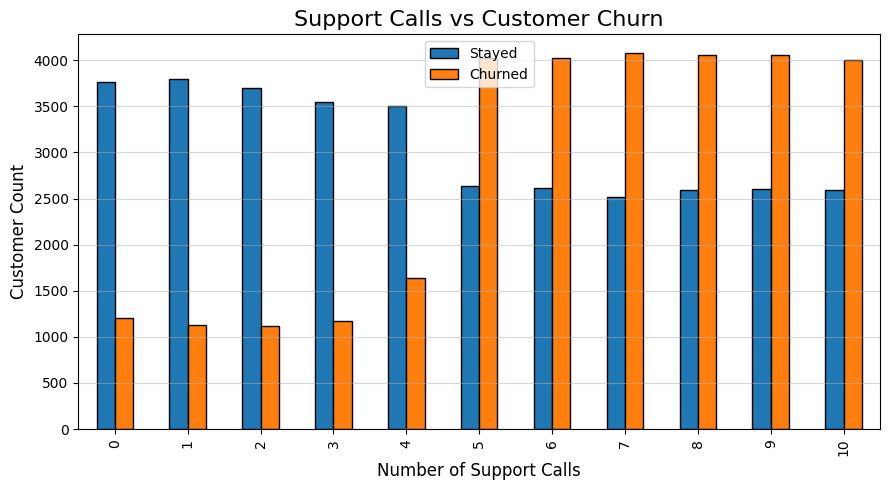

In [ ]:
# support calls vs churn
#If churn increases with more support calls, it suggests customer dissatisfaction.
support_churn = (
    df.groupby(["Support Calls", "Churn"])
      .size()
      .unstack(fill_value=0)
)

support_churn.plot(
    kind="bar",
    figsize=(9,5),
    edgecolor="black"
)

plt.title("Support Calls vs Customer Churn")
plt.xlabel("Number of Support Calls")
plt.ylabel("Customer Count")
plt.legend(["Stayed", "Churned"])
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

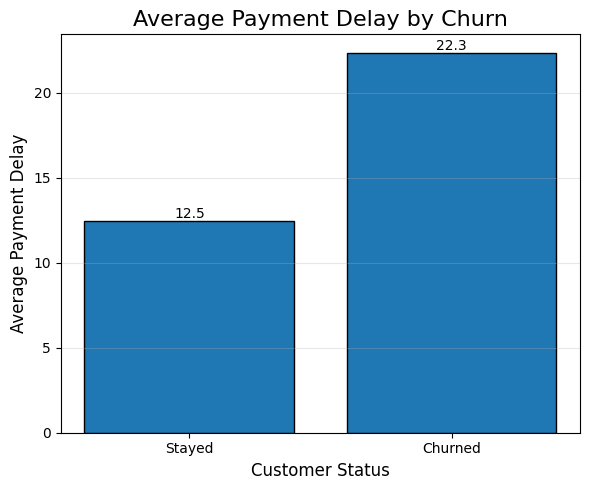

In [57]:
# payment delay vs churn
payment_churn = (
    df.groupby("Churn")["Payment Delay"]
      .mean()
)

plt.figure(figsize=(6,5))

bars = plt.bar(
    ["Stayed", "Churned"],
    payment_churn.values,
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Payment Delay by Churn")
plt.xlabel("Customer Status")
plt.ylabel("Average Payment Delay")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

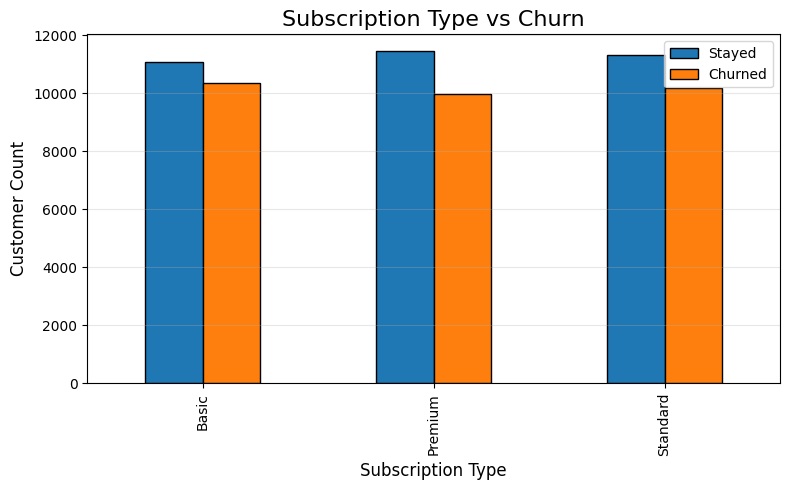

In [58]:
# subscription type vs churn
subscription_churn = (
    df.groupby(["Subscription Type", "Churn"])
      .size()
      .unstack(fill_value=0)
)

subscription_churn.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Subscription Type vs Churn")
plt.xlabel("Subscription Type")
plt.ylabel("Customer Count")
plt.legend(["Stayed", "Churned"])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

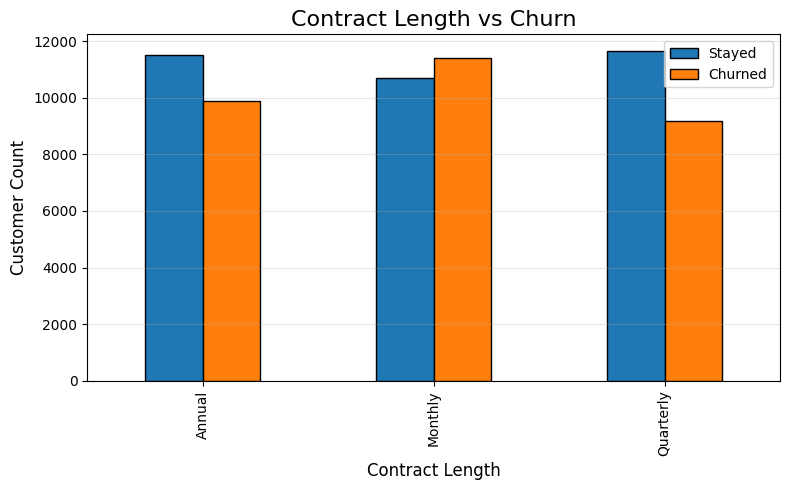

In [60]:
# contract length vs churn
contract_churn = (
    df.groupby(["Contract Length", "Churn"])
      .size()
      .unstack(fill_value=0)
)

contract_churn.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Contract Length vs Churn")
plt.xlabel("Contract Length")
plt.ylabel("Customer Count")
plt.legend(["Stayed", "Churned"])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Longer contracts often improve customer retention

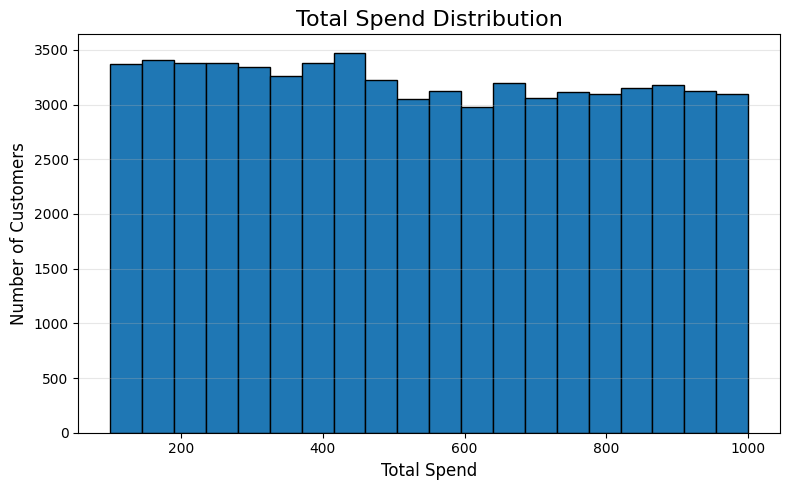

In [61]:
# total spen distribution
plt.figure(figsize=(8,5))

plt.hist(df["Total Spend"], bins=20, edgecolor="black")

plt.title("Total Spend Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
eda_summary = pd.DataFrame({
    "Insight": [
        "Target Balance",
        "Age Distribution",
        "Tenure Distribution",
        "Support Calls",
        "Payment Delay",
        "Subscription Type",
        "Contract Length",
        "Total Spend"
    ],
    "Observation": [
        "See churn distribution plot",
        "Age spread across customers",
        "Tenure varies among customers",
        "Higher support calls may indicate dissatisfaction",
        "Payment delay may relate to churn",
        "Different plans show different churn behavior",
        "Contract duration affects retention",
        "Spending patterns vary across customers"
    ]
})

eda_summary

,Insight,Observation
0,Target Balance,See churn distribution plot
1,Age Distribution,Age spread across customers
2,Tenure Distribution,Tenure varies among customers
3,Support Calls,Higher support calls may indicate dissatisfaction
4,Payment Delay,Payment delay may relate to churn
5,Subscription Type,Different plans show different churn behavior
6,Contract Length,Contract duration affects retention
7,Total Spend,Spending patterns vary across customers
